# Setting up

In [1]:
# IMPORTS
import pandas as pd
import time
import matplotlib.pyplot as plt

In [3]:
# LOAD DATASET

filled_train = pd.read_csv('data/filled_train.csv')


In [4]:
filled_test = pd.read_csv('data/filled_test.csv')

# Date time feature

Some testing

In [5]:
filled_train['date_time'] = pd.to_datetime(filled_train['date_time'])
first_entry = filled_train['date_time'][0]

print(first_entry)

# get the datetime of the first row considering that it is a Timestamp object
month = first_entry.date().month

print(type(month))
print(month)


2013-04-04 08:32:15
<class 'int'>
4


In [12]:
filled_test['date_time'] = pd.to_datetime(filled_test['date_time'])


In [10]:
# get the interval of time between the lowest and highest date_time
max_date = filled_train['date_time'].max()
min_date = filled_train['date_time'].min()

time_interval = filled_train['date_time'].max() - filled_train['date_time'].min()

print(f"The time interval for the training set is between {min_date} and {max_date}\nconsisting of a total time of {time_interval}")

The time interval for the training set is between 2012-11-01 00:08:29 and 2013-06-30 23:58:24
consisting of a total time of 241 days 23:49:55


In [13]:
# do the same for the test set
max_date = filled_test['date_time'].max()

min_date = filled_test['date_time'].min()

time_interval = filled_test['date_time'].max() - filled_test['date_time'].min()

print(f"The time interval for the test set is between {min_date} and {max_date}\nconsisting of a total time of {time_interval}")

The time interval for the test set is between 2012-11-01 00:01:37 and 2013-06-30 23:55:44
consisting of a total time of 241 days 23:54:07


In [6]:
# convert the whole date time column to datetime to an integer representing the month

filled_train['month'] = filled_train['date_time'].apply(lambda x: x.date().month)



In [7]:
filled_train.tail()

,srch_id,date_time,site_id,visitor_location_country_id,visitor_hist_adr_usd,prop_country_id,prop_id,prop_starrating,prop_review_score,prop_brand_bool,...,srch_room_count,srch_saturday_night_bool,srch_query_affinity_score,orig_destination_distance,random_bool,click_bool,booking_bool,comp_rate_agg,comp_inv_agg,month
4958342,332785,2013-06-30 19:55:18,5,219,161.715282,219,77700,3,4.0,1,...,1,0,-85.476396,550.92,0,0,0,0.0,0.0,6
4958343,332785,2013-06-30 19:55:18,5,219,161.715282,219,88083,3,4.0,1,...,1,0,-39.031904,553.14,0,0,0,0.0,0.0,6
4958344,332785,2013-06-30 19:55:18,5,219,161.715282,219,94508,3,3.5,1,...,1,0,-96.114714,544.43,0,0,0,0.0,0.0,6
4958345,332785,2013-06-30 19:55:18,5,219,161.715282,219,128360,3,5.0,1,...,1,0,-140.852009,550.38,0,1,1,0.0,0.0,6
4958346,332785,2013-06-30 19:55:18,5,219,161.715282,219,134949,3,2.5,1,...,1,0,-54.534672,583.25,0,0,0,0.0,0.0,6


In [15]:
month_train = filled_train.drop(columns=['date_time'])

In [14]:
# do the same for the test set
filled_test['date_time'] = pd.to_datetime(filled_test['date_time'])

filled_test['month'] = filled_test['date_time'].apply(lambda x: x.date().month)

month_test = filled_test.drop(columns=['date_time'])

In [16]:
# save the dataset
month_train.to_csv('data/month_train.csv', index=False)

In [17]:
month_test.to_csv('data/month_test.csv', index=False)

# Nights

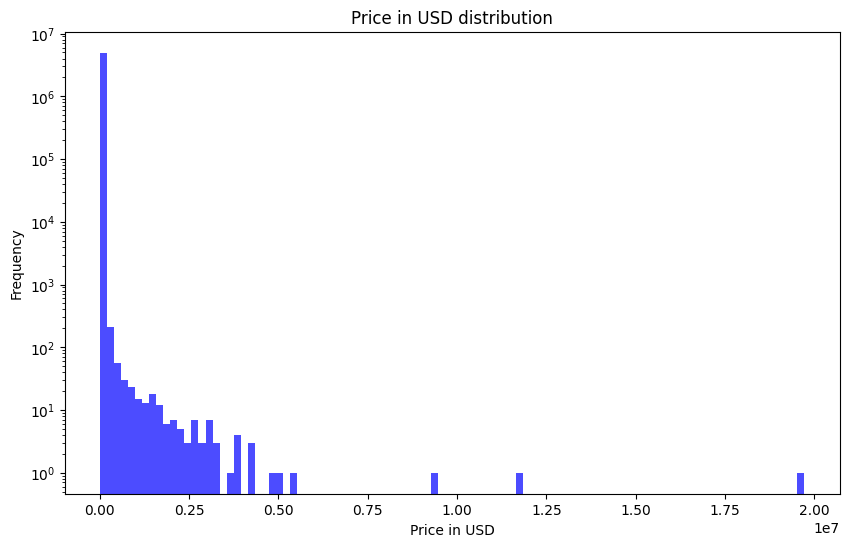

In [24]:
# plot price usd distribution on a log scale on both axes



plt.figure(figsize=(10, 6))

plt.hist(month_train['price_usd'], bins=100, color='blue', alpha=0.7)

plt.yscale('log')


plt.xlabel('Price in USD')

plt.ylabel('Frequency')

plt.title('Price in USD distribution')

plt.show()

In [29]:
# get the maximum price in USD
max_price = month_train['price_usd'].max()
# divide it by srch room count * srch booking window on the same row

# get the index of the row with the maximum price
max_price_index = month_train['price_usd'].idxmax()

# get the srch room count and srch booking window on the same row
srch_room_count = month_train.loc[max_price_index, 'srch_room_count']
srch_booking_window = month_train.loc[max_price_index, 'srch_booking_window']

# divide the maximum price by the product of srch room count and srch booking window
price_per_room = max_price / (srch_room_count * srch_booking_window)
print(f"The maximum price in USD is {max_price}")
print(f"The price per room is {price_per_room}")

# print other information about the row with the maximum price

print(f"The row with the maximum price is {max_price_index}")

print(f"The srch room count is {srch_room_count}")

print(f"The srch booking window is {srch_booking_window}")

# location
location = month_train.loc[max_price_index, 'prop_country_id']

print(f"The location is {location}")

# get the number of rows with the same location

location_count = month_train[month_train['prop_country_id'] == location].shape[0]

print(f"The number of rows with the same location is {location_count}")

# get the number of the property with the maximum price
prop_id = month_train.loc[max_price_index, 'prop_id']

print(f"The property id is {prop_id}")

# get the number of rows with the same property id
prop_count = month_train[month_train['prop_id'] == prop_id].shape[0]

print(f"The number of rows with the same property id is {prop_count}")

# get the mean price for the same property id
mean_price = month_train[month_train['prop_id'] == prop_id]['price_usd'].mean()

print(f"The mean price for the same property id is {mean_price}")

# get the mean price for the same location

mean_price = month_train[month_train['prop_country_id'] == location]['price_usd'].mean()

print(f"The mean price for the same location is {mean_price}")




The maximum price in USD is 19726328.0
The price per room is 2818046.8571428573
The row with the maximum price is 1168566
The srch room count is 1
The srch booking window is 7
The location is 39
The number of rows with the same location is 28054
The property id is 39677
The number of rows with the same property id is 262
The mean price for the same property id is 75970.27019083967
The mean price for the same location is 3470.3072282027524


In [33]:
prices_of_the_property = month_train[month_train['prop_id'] == prop_id]['price_usd']

print(prices_of_the_property)

75018       490.82
84367       482.00
115662      392.42
154739      527.63
160630      362.95
            ...   
4891960    2579.81
4911205     428.10
4914996     436.98
4922165     484.06
4934853     808.96
Name: price_usd, Length: 262, dtype: float64


In [35]:
# get the number of prices that are greater than 1 million
prices_greater_than_1M = month_train[month_train['price_usd'] > 1000000]
print(f"The number of prices greater than 1 million is {prices_greater_than_1M.shape[0]}")

The number of prices greater than 1 million is 113


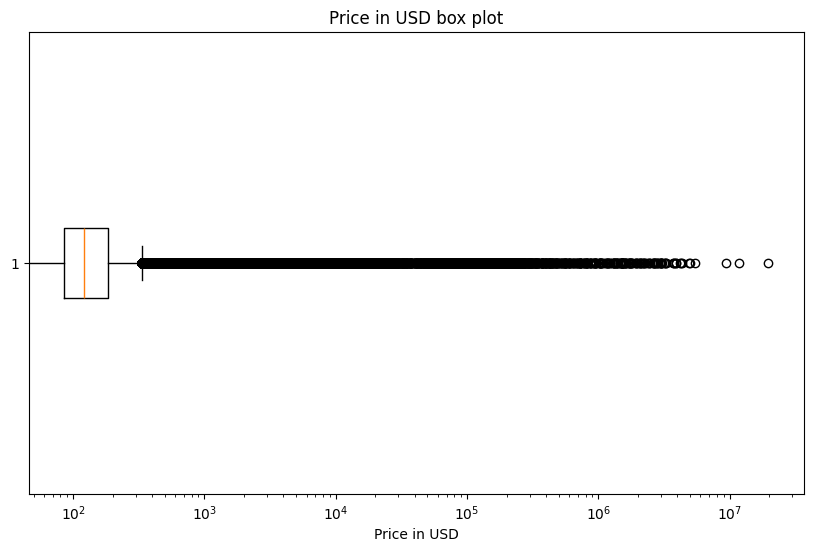

In [36]:
# log box plot of the prices
plt.figure(figsize=(10, 6))

plt.boxplot(month_train['price_usd'], vert=False)

plt.xscale('log')

plt.xlabel('Price in USD')

plt.title('Price in USD box plot')

plt.show()



In [37]:
#count the number of outliers
# get the first and third quartile

Q1 = month_train['price_usd'].quantile(0.25)

Q3 = month_train['price_usd'].quantile(0.75)

# get the interquartile range

IQR = Q3 - Q1

# get the lower and upper bounds

lower_bound = Q1 - 1.5 * IQR

upper_bound = Q3 + 1.5 * IQR

# get the number of outliers

outliers = month_train[(month_train['price_usd'] < lower_bound) | (month_train['price_usd'] > upper_bound)]

print(f"The number of outliers is {outliers.shape[0]}")

The number of outliers is 294480


Text(0.5, 1.0, 'Price in USD distribution without outliers')

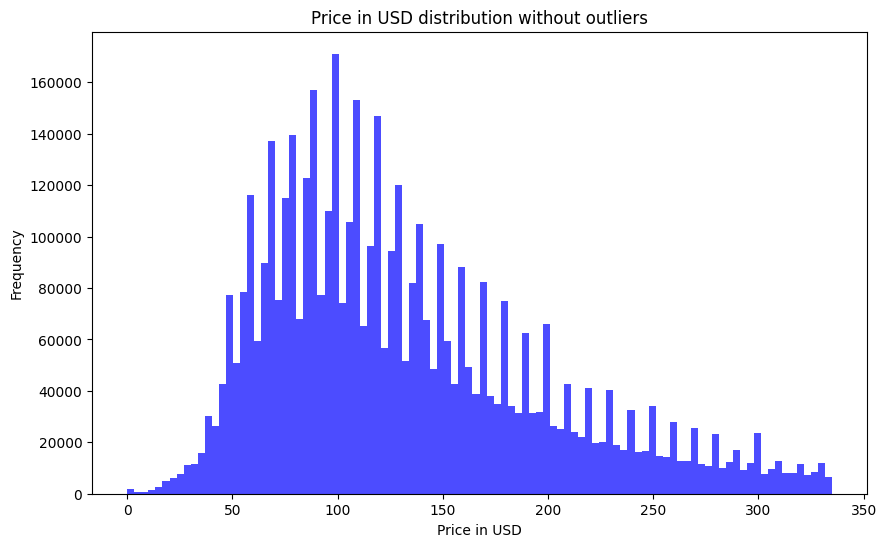

In [38]:
# plot the distribution of the price in USD without the outliers

plt.figure(figsize=(10, 6))

plt.hist(month_train[(month_train['price_usd'] > lower_bound) & (month_train['price_usd'] < upper_bound)]['price_usd'], bins=100, color='blue', alpha=0.7)


plt.xlabel('Price in USD')

plt.ylabel('Frequency')

plt.title('Price in USD distribution without outliers')


The number of values higher than 10000 is 1994


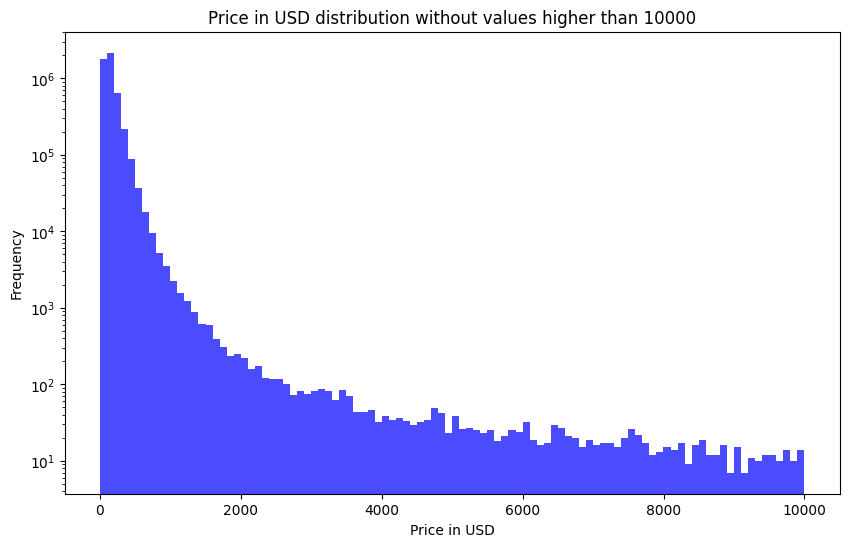

In [40]:
# plot the distribution withouth values higher than 10000 (count them)

plt.figure(figsize=(10, 6))

mask = month_train['price_usd'] < 10000

print(f"The number of values higher than 10000 is {month_train[~mask].shape[0]}")

plt.hist(month_train[mask]['price_usd'], bins=100, color='blue', alpha=0.7)

plt.yscale('log')

plt.xlabel('Price in USD')

plt.ylabel('Frequency')

plt.title('Price in USD distribution without values higher than 10000')

plt.show()


The number of values higher than 10000 is 1947


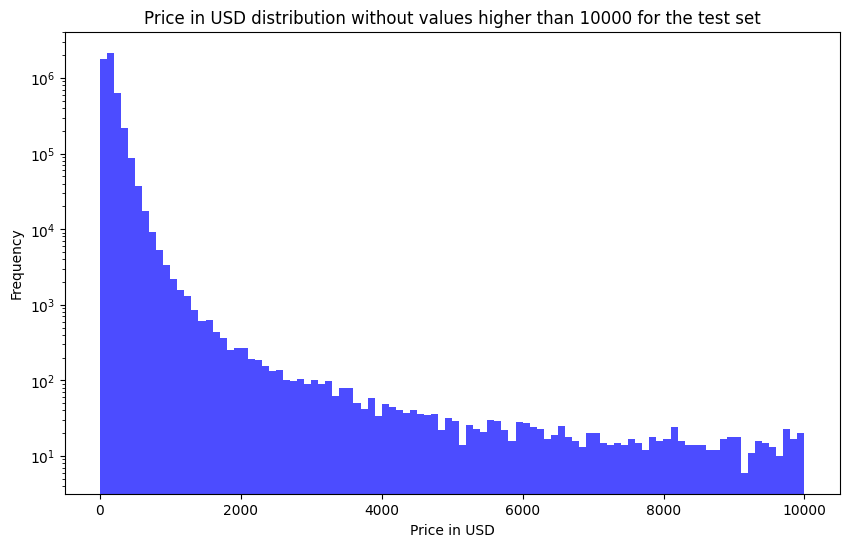

In [41]:
# distribution of the price in USD for the test set

plt.figure(figsize=(10, 6))

mask = month_test['price_usd'] < 10000

print(f"The number of values higher than 10000 is {month_test[~mask].shape[0]}")

plt.hist(month_test[mask]['price_usd'], bins=100, color='blue', alpha=0.7)

plt.yscale('log')

plt.xlabel('Price in USD')

plt.ylabel('Frequency')

plt.title('Price in USD distribution without values higher than 10000 for the test set')

plt.show()

In [66]:
# add the total number of nights row

month_train['total_nights'] = month_train['srch_length_of_stay'] * month_train['srch_room_count']

month_test['total_nights'] = month_test['srch_length_of_stay'] * month_test['srch_room_count']


# set 0 values in the total nights column to 1

month_train['total_nights'] = month_train['total_nights'].apply(lambda x: 1 if x == 0 else x)

month_test['total_nights'] = month_test['total_nights'].apply(lambda x: 1 if x == 0 else x)
 

int64
int64


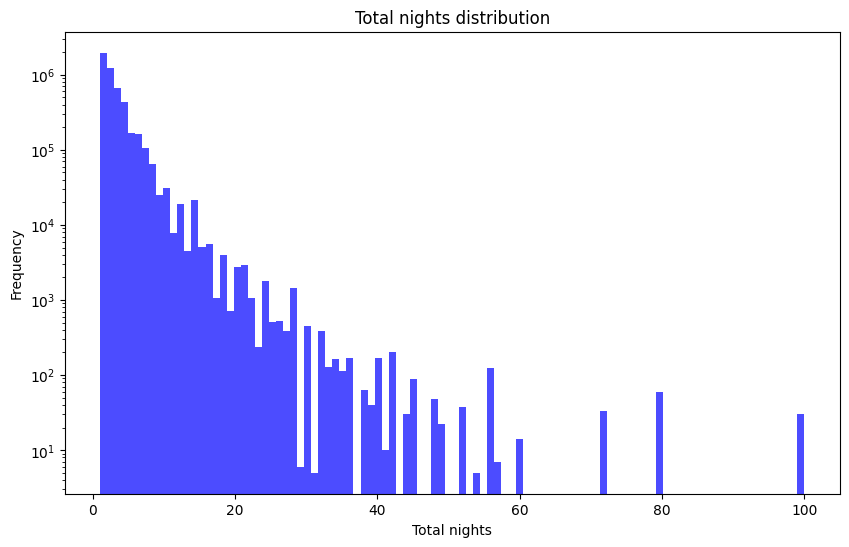

In [67]:
# plot them on a log scale

plt.figure(figsize=(10, 6))

plt.hist(month_train['total_nights'], bins=100, color='blue', alpha=0.7)

plt.yscale('log')

plt.xlabel('Total nights')

plt.ylabel('Frequency')

plt.title('Total nights distribution')

plt.show()

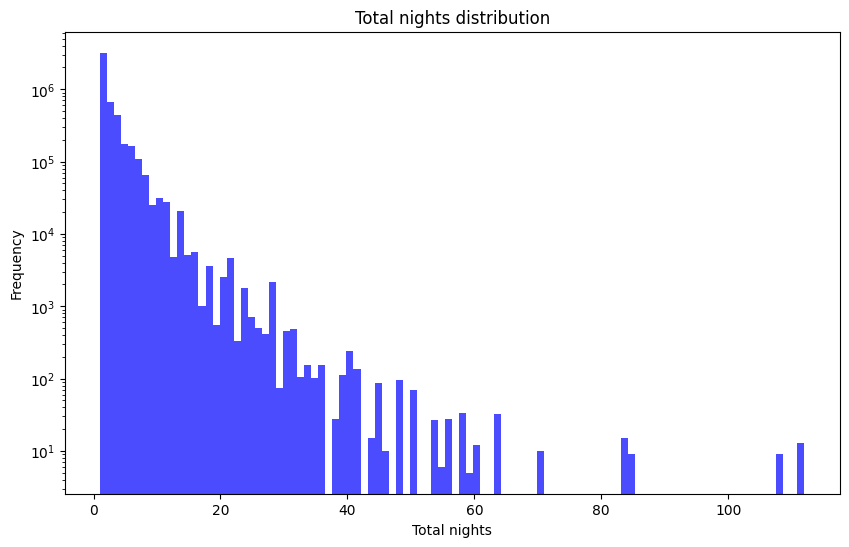

In [68]:
plt.figure(figsize=(10, 6))

plt.hist(month_test['total_nights'], bins=100, color='blue', alpha=0.7)

plt.yscale('log')

plt.xlabel('Total nights')

plt.ylabel('Frequency')

plt.title('Total nights distribution')

plt.show()

In [69]:
# add the price per night row

month_train['price_per_night'] = month_train['price_usd'] / month_train['total_nights']

month_test['price_per_night'] = month_test['price_usd'] / month_test['total_nights']



## Logarithms

In [49]:
# count the number of prices that are less than 1

prices_less_than_1 = month_train[month_train['price_usd'] < 1]

In [53]:
# count the number of booked rows with price less than 1

booked_prices_less_than_1 = month_train[(month_train['price_usd'] < 1) & (month_train['booking_bool'] == 1)]

print(f"The number of prices less than 1 is {prices_less_than_1.shape[0]}")

print(f"The number of booked prices less than 1 is {booked_prices_less_than_1.shape[0]}")

# print the number of different searches prices_less_than_1

print(f"The number of different searches with prices less than 1 is {prices_less_than_1['srch_id'].nunique()}")



The number of prices less than 1 is 963
The number of booked prices less than 1 is 36
The number of different searches with prices less than 1 is 60


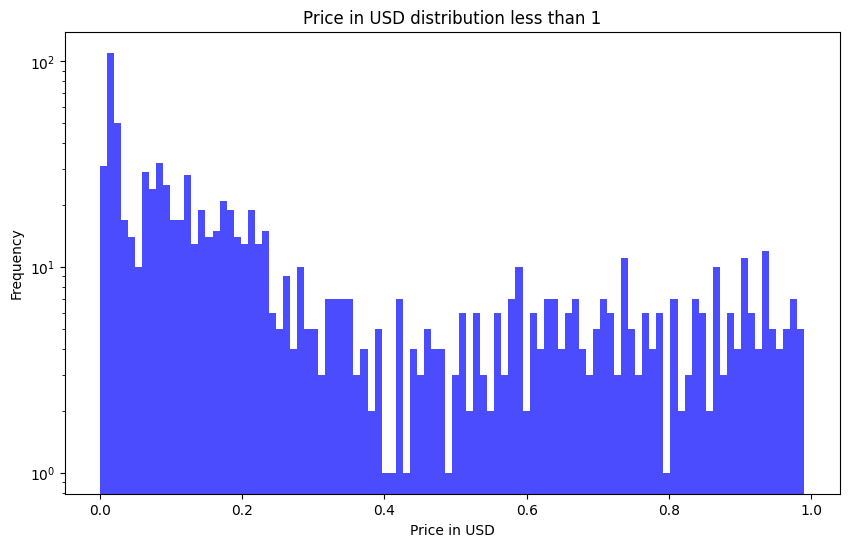

In [54]:
# plot the distribution of the prices less than 1

plt.figure(figsize=(10, 6))

plt.hist(prices_less_than_1['price_usd'], bins=100, color='blue', alpha=0.7)

plt.yscale('log')

plt.xlabel('Price in USD')

plt.ylabel('Frequency')

plt.title('Price in USD distribution less than 1')

plt.show()


In [58]:
print(f"The number of prices == 0 is {month_train[month_train['price_usd'] == 0].shape[0]}")

The number of prices == 0 is 31


In [57]:
import numpy as np

np.log(-1)

/var/folders/d8/_xc_qyn9121fv2fflg18bqxc0000gn/T/ipykernel_9695/1089054615.py:3: RuntimeWarning: invalid value encountered in log
  np.log(-1)


nan

In [50]:
prices_less_than_1

,srch_id,site_id,visitor_location_country_id,visitor_hist_adr_usd,prop_country_id,prop_id,prop_starrating,prop_review_score,prop_brand_bool,prop_location_score1,...,orig_destination_distance,random_bool,click_bool,booking_bool,comp_rate_agg,comp_inv_agg,month,total_nights,price_per_night,log_price_usd
276808,18538,22,92,212.268414,219,743,3,3.5,1,1.61,...,856.156047,0,0,0,0.0,-2.5,6,1,0.110000,-2.207275
276809,18538,22,92,212.268414,219,4571,3,4.0,1,2.83,...,856.156047,0,0,0,0.0,-2.5,6,1,0.150000,-1.897120
276810,18538,22,92,212.268414,219,15267,2,3.5,1,3.00,...,856.156047,0,0,0,0.0,-1.5,6,1,0.130000,-2.040221
276811,18538,22,92,212.268414,219,16687,3,4.0,1,3.09,...,856.156047,0,1,1,0.0,-2.0,6,1,0.160000,-1.832581
276812,18538,22,92,212.268414,219,18651,3,3.5,1,3.00,...,856.156047,0,0,0,0.0,-1.5,6,1,0.180000,-1.714798
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4953234,332449,24,219,161.715282,219,23552,3,3.5,0,3.58,...,807.930000,0,0,0,2.0,-1.5,5,3,0.223333,-0.400478
4953237,332449,24,219,161.715282,219,42693,3,3.5,1,3.50,...,808.330000,0,0,0,0.0,-1.5,5,3,0.303333,-0.094311
4953238,332449,24,219,161.715282,219,45896,4,3.5,1,3.14,...,808.550000,0,0,0,0.0,-1.5,5,3,0.286667,-0.150823
4953250,332449,24,219,161.715282,219,105796,3,3.5,0,3.53,...,807.520000,0,0,0,0.0,-1.0,5,3,0.290000,-0.139262


the minimum value is -4.605170185988091


/Users/michele/computer_science/code/DMT-assignment-2/.venv/lib/python3.12/site-packages/pandas/core/arraylike.py:399: RuntimeWarning: divide by zero encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)


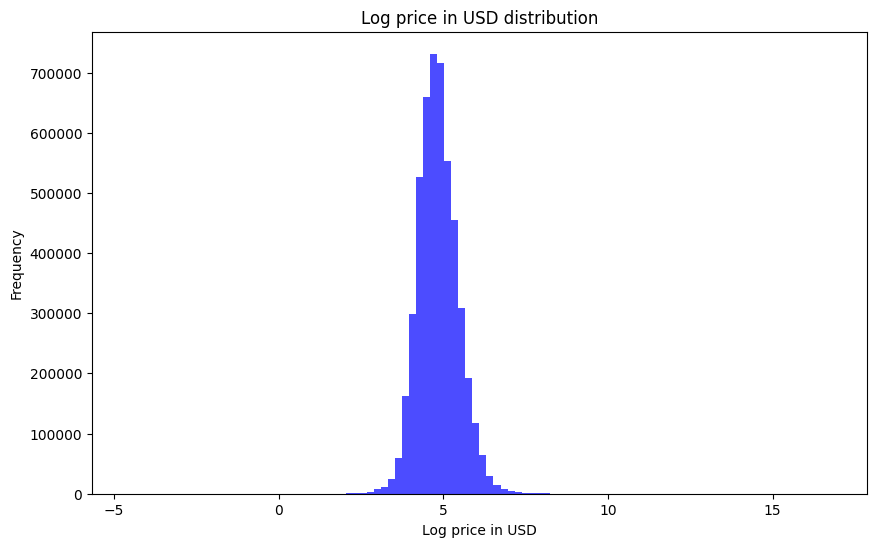

In [70]:
# add the logarithm of usd price  as a new column

from numpy import log

# log prices
log_price_train = log(month_train['price_usd'])

min = log_price_train[log_price_train != -np.inf].min()

print(f"the minimum value is {min}")

# replace -inf with the minimum value

log_price_train = log_price_train.replace(-np.inf, min)

log_price_test = log(month_test['price_usd']).replace(-np.inf, min)


month_train['log_price_usd'] = log_price_train

month_test['log_price_usd'] = log_price_test

# plot the distribution of the log price in USD

plt.figure(figsize=(10, 6))

plt.hist(month_train['log_price_usd'], bins=100, color='blue', alpha=0.7)

plt.xlabel('Log price in USD')

plt.ylabel('Frequency')

plt.title('Log price in USD distribution')

plt.show()







the minimum value is -7.438383530044307


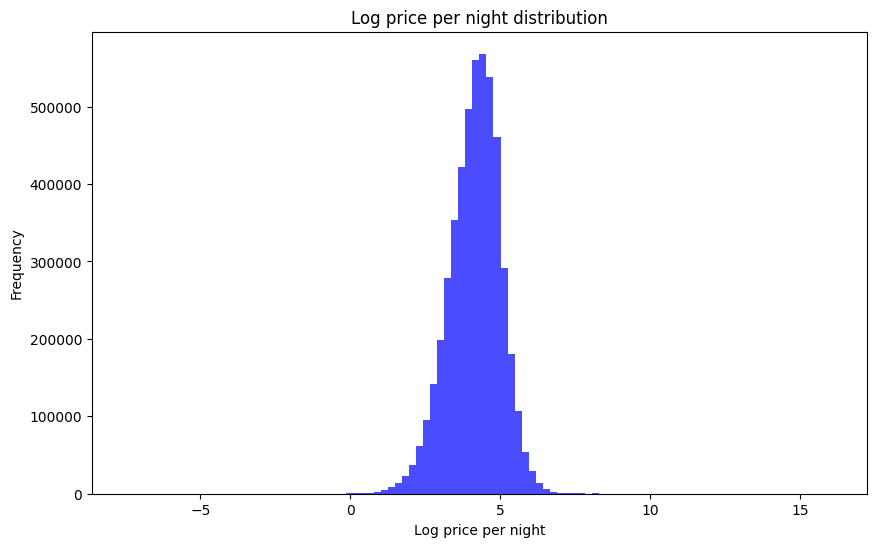

In [71]:
# do the same for the log of price per night

log_price_per_night_train = log(month_train['price_per_night'])

min = log_price_per_night_train[log_price_per_night_train != -np.inf].min()

print(f"the minimum value is {min}")

# replace -inf with the minimum value

log_price_per_night_train = log_price_per_night_train.replace(-np.inf, min)

log_price_per_night_test = log(month_test['price_per_night']).replace(-np.inf, min)


month_train['log_price_per_night'] = log_price_per_night_train

month_test['log_price_per_night'] = log_price_per_night_test

# plot the distribution of the log price per night

plt.figure(figsize=(10, 6))

plt.hist(month_train['log_price_per_night'], bins=100, color='blue', alpha=0.7)

plt.xlabel('Log price per night')

plt.ylabel('Frequency')

plt.title('Log price per night distribution')

plt.show()

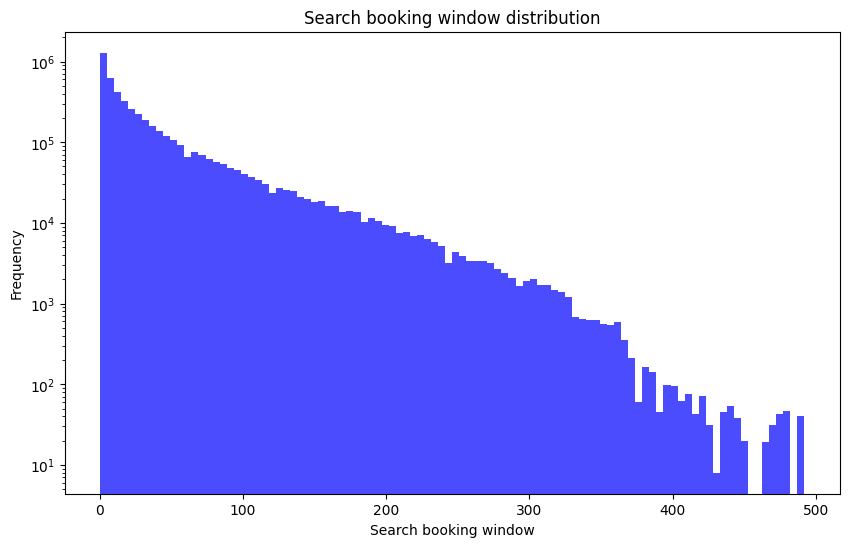

In [62]:
# plot the distribution of booking window and length of stay

plt.figure(figsize=(10, 6))

plt.hist(month_train['srch_booking_window'], bins=100, color='blue', alpha=0.7)

plt.yscale('log')

plt.xlabel('Search booking window')

plt.ylabel('Frequency')

plt.title('Search booking window distribution')

plt.show()


In [64]:
# count the number of booking windows  == 0

print(f"The number of booking windows == 1 is {month_train[month_train['srch_booking_window'] == 1].shape[0]}")

The number of booking windows == 1 is 374949
